# Phase 2 - Create Silver Flight-Weather Labels and Gold Features

This notebook joins real BTS flight outcomes with daily airport weather aggregates and creates leakage-conscious Gold features.

Production counterparts:

- `spark_jobs/build_silver_flight_weather.py`
- `spark_jobs/build_gold_features.py`

The current proof uses daily weather aggregates because BTS scheduled departure time is local while ARCO weather is UTC. A timezone dimension is required before switching to an hourly join.

In [1]:
import sys
from pathlib import Path
from IPython.display import display
from pyspark.sql import functions as F
PROJECT_ROOT = Path("/workspace")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from spark_jobs.common import create_spark_session, load_settings, s3a_uri
from spark_jobs.build_gold_features import CATEGORICAL_FEATURES, NUMERIC_FEATURES

YEAR, MONTH = 2024, 1
WRITE_TABLES = False  # Set True to rebuild verified Silver and Gold partitions.
settings = load_settings()
spark = create_spark_session("phase2-silver-gold-original-data", settings)
weather_source = s3a_uri(settings.lakehouse_bucket, f"bronze/weather/year={YEAR}/month={MONTH:02d}")
flights_source = s3a_uri(settings.lakehouse_bucket, f"bronze/bts_on_time/year={YEAR}/month={MONTH:02d}")
airports_source = s3a_uri(settings.raw_bucket, "metadata/ourairports/us_airports_selected_with_era5_grid.parquet")
silver_destination = s3a_uri(settings.lakehouse_bucket, f"silver/flight_weather_daily/year={YEAR}/month={MONTH:02d}")
gold_destination = s3a_uri(settings.lakehouse_bucket, f"gold/training_features/year={YEAR}/month={MONTH:02d}")

## Map Flight Origins to Weather Airport Keys

In [2]:
weather_df = spark.read.parquet(weather_source)
flights_df = spark.read.parquet(flights_source)
airports_df = spark.read.parquet(airports_source)

airport_dim = (
    airports_df.filter(F.col("iata_code").isNotNull())
    .groupBy(F.upper("iata_code").alias("origin"))
    .agg(F.min(F.col("airport_key").cast("int")).alias("airport_key"))
)
airport_dim.show(10, truncate=False)

+------+-----------+
|origin|airport_key|
+------+-----------+
|BZT   |3074       |
|BKF   |6022       |
|WYB   |7221       |
|NKI   |9396       |
|CYM   |10174      |
|HKB   |10681      |
|HYL   |10684      |
|HUD   |11239      |
|CNE   |11380      |
|FPY   |11600      |
+------+-----------+
only showing top 10 rows


## Aggregate Hourly Weather to Airport-Day

In [3]:
weather_daily_df = (
    weather_df.withColumn("weather_date", F.to_date("time_utc"))
    .groupBy("airport_key", "weather_date")
    .agg(
        F.avg("temperature_c").alias("temperature_c_avg"),
        F.max("wind_speed_kts").alias("wind_speed_kts_max"),
        F.max("wind_gust_kts").alias("wind_gust_kts_max"),
        F.sum("precipitation_mm").alias("precipitation_mm_sum"),
        F.avg("surface_pressure_pa").alias("surface_pressure_pa_avg"),
        F.avg("total_cloud_cover").alias("total_cloud_cover_avg"),
        F.max("cape_j_kg").alias("cape_j_kg_max"),
    )
)
weather_daily_df.show(10, truncate=False)

+-----------+------------+--------------------+------------------+------------------+---------------------+-----------------------+---------------------+-------------+
|airport_key|weather_date|temperature_c_avg   |wind_speed_kts_max|wind_gust_kts_max |precipitation_mm_sum |surface_pressure_pa_avg|total_cloud_cover_avg|cape_j_kg_max|
+-----------+------------+--------------------+------------------+------------------+---------------------+-----------------------+---------------------+-------------+
|10002      |2024-01-01  |8.249567921956404   |4.409900323970971 |11.650130204467773|0.0016763806343078613|97334.62239583333      |0.3935447347660859   |2.068359375  |
|10004      |2024-01-01  |12.59903233846031   |9.06502365921862  |13.921992833709718|0.0                  |101502.18587239583     |0.371802502622207    |0.689453125  |
|10031      |2024-01-01  |0.004109954834007112|5.465422013721875 |13.214401082611085|0.0                  |82846.37955729167      |0.19939127440253893  |26.7441

## Create Silver with Real BTS Outcome Labels

A flight is labeled disrupted when it was cancelled or arrived at least 15 minutes late. Outcome fields remain in Silver for auditing but are excluded from Gold model features.

In [4]:
mapped_flights_df = flights_df.join(F.broadcast(airport_dim), "origin", "left").alias("flights")
weather_daily_df = weather_daily_df.alias("weather")

joined_df = (
    mapped_flights_df.join(
        weather_daily_df,
        (F.col("flights.airport_key") == F.col("weather.airport_key")) &
        (F.col("flights.flight_date") == F.col("weather.weather_date")),
        "left",
    )
    .select(
        "flights.*", "weather.weather_date", "weather.temperature_c_avg",
        "weather.wind_speed_kts_max", "weather.wind_gust_kts_max",
        "weather.precipitation_mm_sum", "weather.surface_pressure_pa_avg",
        "weather.total_cloud_cover_avg", "weather.cape_j_kg_max",
    )
)

silver_df = (
    joined_df.filter(F.col("weather_date").isNotNull())
    .withColumn(
        "label",
        F.when(
            (F.coalesce(F.col("cancelled"), F.lit(0.0)) >= 1.0) |
            (F.coalesce(F.col("arrival_delay_minutes"), F.lit(0.0)) >= 15.0),
            F.lit(1.0),
        ).otherwise(F.lit(0.0)),
    )
    .withColumn("label_source", F.lit("BTS_REAL_OUTCOME"))
    .drop("weather_date")
)

flight_count = flights_df.count()
matched_count = silver_df.count()
print("BTS flight rows:", flight_count)
print("Rows matched to weather:", matched_count)
print("Rows without weather match:", flight_count - matched_count)
silver_df.groupBy("label", "label_source").count().orderBy("label").show()

BTS flight rows: 547271
Rows matched to weather: 543121
Rows without weather match: 4150


+-----+----------------+------+
|label|    label_source| count|
+-----+----------------+------+
|  0.0|BTS_REAL_OUTCOME|397465|
|  1.0|BTS_REAL_OUTCOME|145656|
+-----+----------------+------+



## Create Gold Features Without Target Leakage

In [5]:
gold_df = (
    silver_df
    .withColumn("day_of_week", F.dayofweek("flight_date").cast("double"))
    .withColumn("day_of_month", F.dayofmonth("flight_date").cast("double"))
    .select(
        "flight_date", "origin", "destination", "reporting_airline",
        *NUMERIC_FEATURES,
        F.col("label").cast("double").alias("label"), "label_source",
    )
    .dropna(subset=CATEGORICAL_FEATURES + NUMERIC_FEATURES + ["label"])
)

print("Numeric model features:", NUMERIC_FEATURES)
print("Categorical model features:", CATEGORICAL_FEATURES)
print("Gold rows:", gold_df.count())
gold_df.show(10, truncate=False)

Numeric model features: ['scheduled_departure_hour_local', 'distance_miles', 'day_of_week', 'day_of_month', 'temperature_c_avg', 'wind_speed_kts_max', 'wind_gust_kts_max', 'precipitation_mm_sum', 'surface_pressure_pa_avg', 'total_cloud_cover_avg', 'cape_j_kg_max']
Categorical model features: ['origin', 'reporting_airline']


Gold rows: 543121


+-----------+------+-----------+-----------------+------------------------------+--------------+-----------+------------+--------------------+------------------+------------------+--------------------+-----------------------+---------------------+---------------+-----+----------------+
|flight_date|origin|destination|reporting_airline|scheduled_departure_hour_local|distance_miles|day_of_week|day_of_month|temperature_c_avg   |wind_speed_kts_max|wind_gust_kts_max |precipitation_mm_sum|surface_pressure_pa_avg|total_cloud_cover_avg|cape_j_kg_max  |label|label_source    |
+-----------+------+-----------+-----------------+------------------------------+--------------+-----------+------------+--------------------+------------------+------------------+--------------------+-----------------------+---------------------+---------------+-----+----------------+
|2024-01-01 |BFF   |DEN        |OO               |18                            |150.0         |2.0        |1.0         |0.0077224731445539

Using verified stored outputs. Set WRITE_TABLES=True to rebuild.


,label,count
0,0.0,397465
1,1.0,145656


<Axes: title={'center': 'January 2024 BTS disruption labels'}, xlabel='label'>

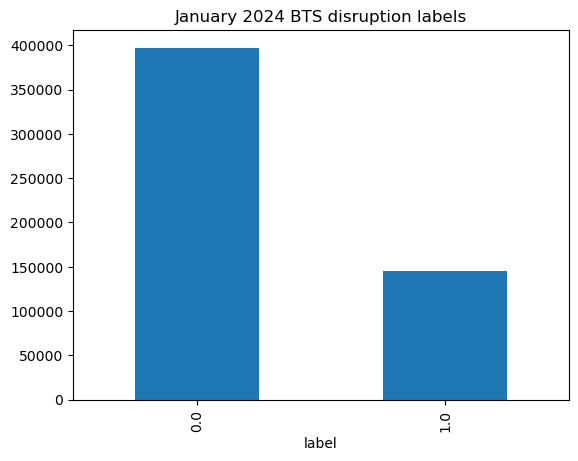

In [6]:
if WRITE_TABLES:
    silver_df.write.mode("overwrite").parquet(silver_destination)
    gold_df.write.mode("overwrite").parquet(gold_destination)
    print("Rebuilt Silver and Gold partitions.")
else:
    print("Using verified stored outputs. Set WRITE_TABLES=True to rebuild.")

label_counts = gold_df.groupBy("label").count().orderBy("label").toPandas()
display(label_counts)
label_counts.plot.bar(x="label", y="count", title="January 2024 BTS disruption labels", legend=False)

## Verified Silver and Gold Results

- BTS flight rows: **547,271**
- Flights matched to weather: **543,121**
- Flights without weather match: **4,150**
- Non-disrupted flights: **397,465**
- Disrupted flights: **145,656**
- Gold rows after required-feature filtering: **543,121**

In [7]:
spark.stop()